In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import kruskal, mannwhitneyu

PROC_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results")

uncertainty = pd.read_csv(RESULTS_DIR / "uncertainty_per_patient.csv")
cp_results = pd.read_csv(RESULTS_DIR / "conformal_results.csv")

clinical = pd.read_csv(PROC_DIR / "clinical_final.csv")
print("clinical index col:", clinical.columns[0])
print("clinical shape:", clinical.shape)

clinical = clinical.set_index('cbio_patient_id')

merged = uncertainty.merge(clinical[['ELN2017_clean', 'FLT3_ITD', 'NPM1']],
                           left_on='cbio_patient_id', right_index=True, how='left')
print("\nafter merging with clinical:")
print("records:", len(merged))
print("ELN2017 coverage:", merged['ELN2017_clean'].notna().sum())
print("FLT3_ITD coverage:", merged['FLT3_ITD'].notna().sum())
print("NPM1 coverage:", merged['NPM1'].notna().sum())

clinical index col: cbio_patient_id
clinical shape: (318, 8)

after merging with clinical:
records: 7000
ELN2017 coverage: 6642
FLT3_ITD coverage: 6899
NPM1 coverage: 6899


Mean interval width by ELN2017 subtype:
  Favorable: 157.73 ± 37.28 (n=1757)
  Intermediate: 158.76 ± 36.88 (n=1050)
  Adverse: 157.73 ± 37.14 (n=1595)
  NonInitial: 159.04 ± 36.44 (n=2240)

Kruskal-Wallis: H=2.9807, p=0.3946


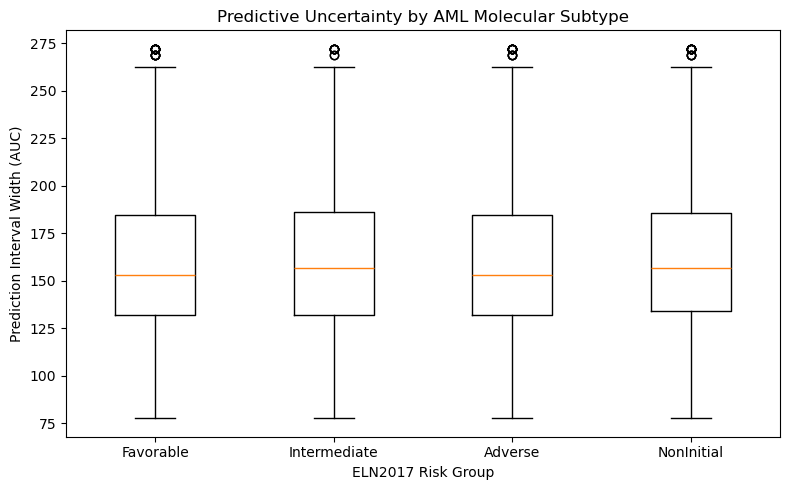

Saved.


In [15]:
# uncertainty by ELN2017 subtype

eln_groups = ['Favorable', 'Intermediate', 'Adverse', 'NonInitial']

eln_data = {}
for g in eln_groups:
    eln_data[g] = merged.loc[merged['ELN2017_clean'] == g, 'width'].values

print("Mean interval width by ELN2017 subtype:")
for g in eln_groups:
    print(f"  {g}: {eln_data[g].mean():.2f} ± {eln_data[g].std():.2f} (n={len(eln_data[g])})")

stat, p = kruskal(*[eln_data[g] for g in eln_groups])
print(f"\nKruskal-Wallis: H={stat:.4f}, p={p:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([eln_data[g] for g in eln_groups], tick_labels=eln_groups)
ax.set_ylabel("Prediction Interval Width (AUC)")
ax.set_xlabel("ELN2017 Risk Group")
ax.set_title("Predictive Uncertainty by AML Molecular Subtype")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures/uncertainty_by_ELN2017.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")


FLT3-ITD mutation status:
  Negative: 157.78 ± 36.88 (n=4899)
  Positive: 159.92 ± 36.89 (n=2000)
  Mann-Whitney U: p=0.0136

NPM1 mutation status:
  Negative: 158.35 ± 36.97 (n=4847)
  Positive: 158.53 ± 36.73 (n=2052)
  Mann-Whitney U: p=0.7875


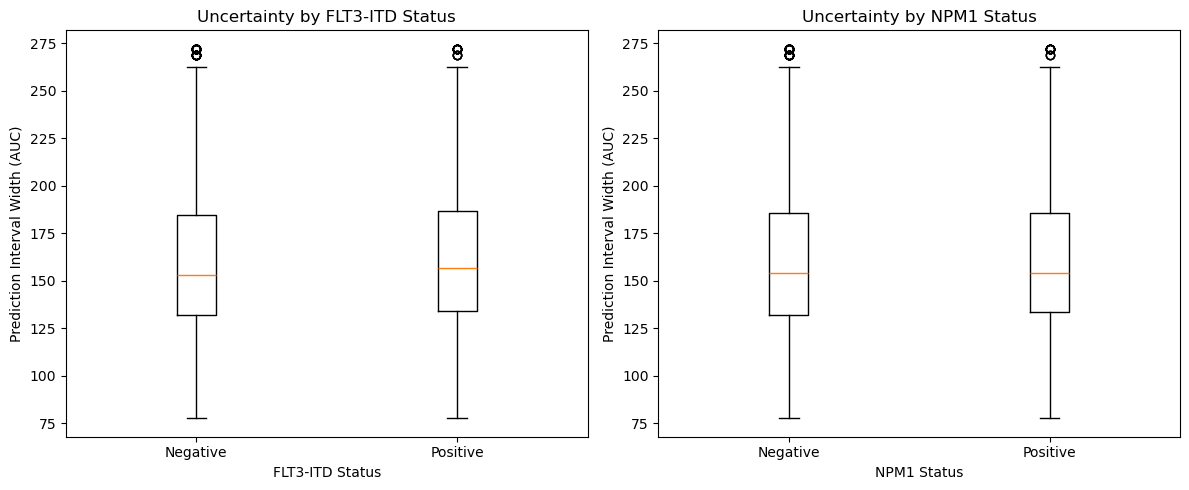

Saved.


In [16]:
#  uncertainty by FLT3_ITD and NPM1 mutation status

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes, ['FLT3_ITD', 'NPM1'], ['FLT3-ITD', 'NPM1']):
    groups = merged[col].dropna().unique()
    data = {g: merged.loc[merged[col] == g, 'width'].values for g in groups}
    
    print(f"\n{title} mutation status:")
    for g in groups:
        print(f"  {g}: {data[g].mean():.2f} ± {data[g].std():.2f} (n={len(data[g])})")
    
    if len(groups) == 2:
        g0, g1 = groups
        stat, p = mannwhitneyu(data[g0], data[g1], alternative='two-sided')
        print(f"  Mann-Whitney U: p={p:.4f}")
    else:
        stat, p = kruskal(*data.values())
        print(f"  Kruskal-Wallis: p={p:.4f}")
    
    ax.boxplot(list(data.values()), tick_labels=[str(g) for g in groups])
    ax.set_title(f"Uncertainty by {title} Status")
    ax.set_ylabel("Prediction Interval Width (AUC)")
    ax.set_xlabel(f"{title} Status")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures/uncertainty_by_mutations.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

top 10 highest uncertainty drugs:
                   drug  mean_width  std_width
             Venetoclax    272.1114        0.0
    Tandutinib (MLN518)    269.0634        0.0
 Lestaurtinib (CEP-701)    262.2710        0.0
           Panobinostat    260.2840        0.0
             Lovastatin    254.1648        0.0
   Bortezomib (Velcade)    237.3941        0.0
                BI-2536    232.4231        0.0
Gilteritinib (ASP-2215)    229.4914        0.0
              Selinexor    226.3431        0.0
 Doramapimod (BIRB 796)    220.0805        0.0

top 10 lowest uncertainty drugs:
                    drug  mean_width  std_width
            Lenalidomide    106.4995        0.0
              BMS-345541    105.5311        0.0
             Bay 11-7085    102.6808        0.0
Ruxolitinib (INCB018424)    102.5186        0.0
              CHIR-99021     99.2321        0.0
   Vismodegib (GDC-0449)     99.0442        0.0
               Lapatinib     95.5868        0.0
                  STO609     83

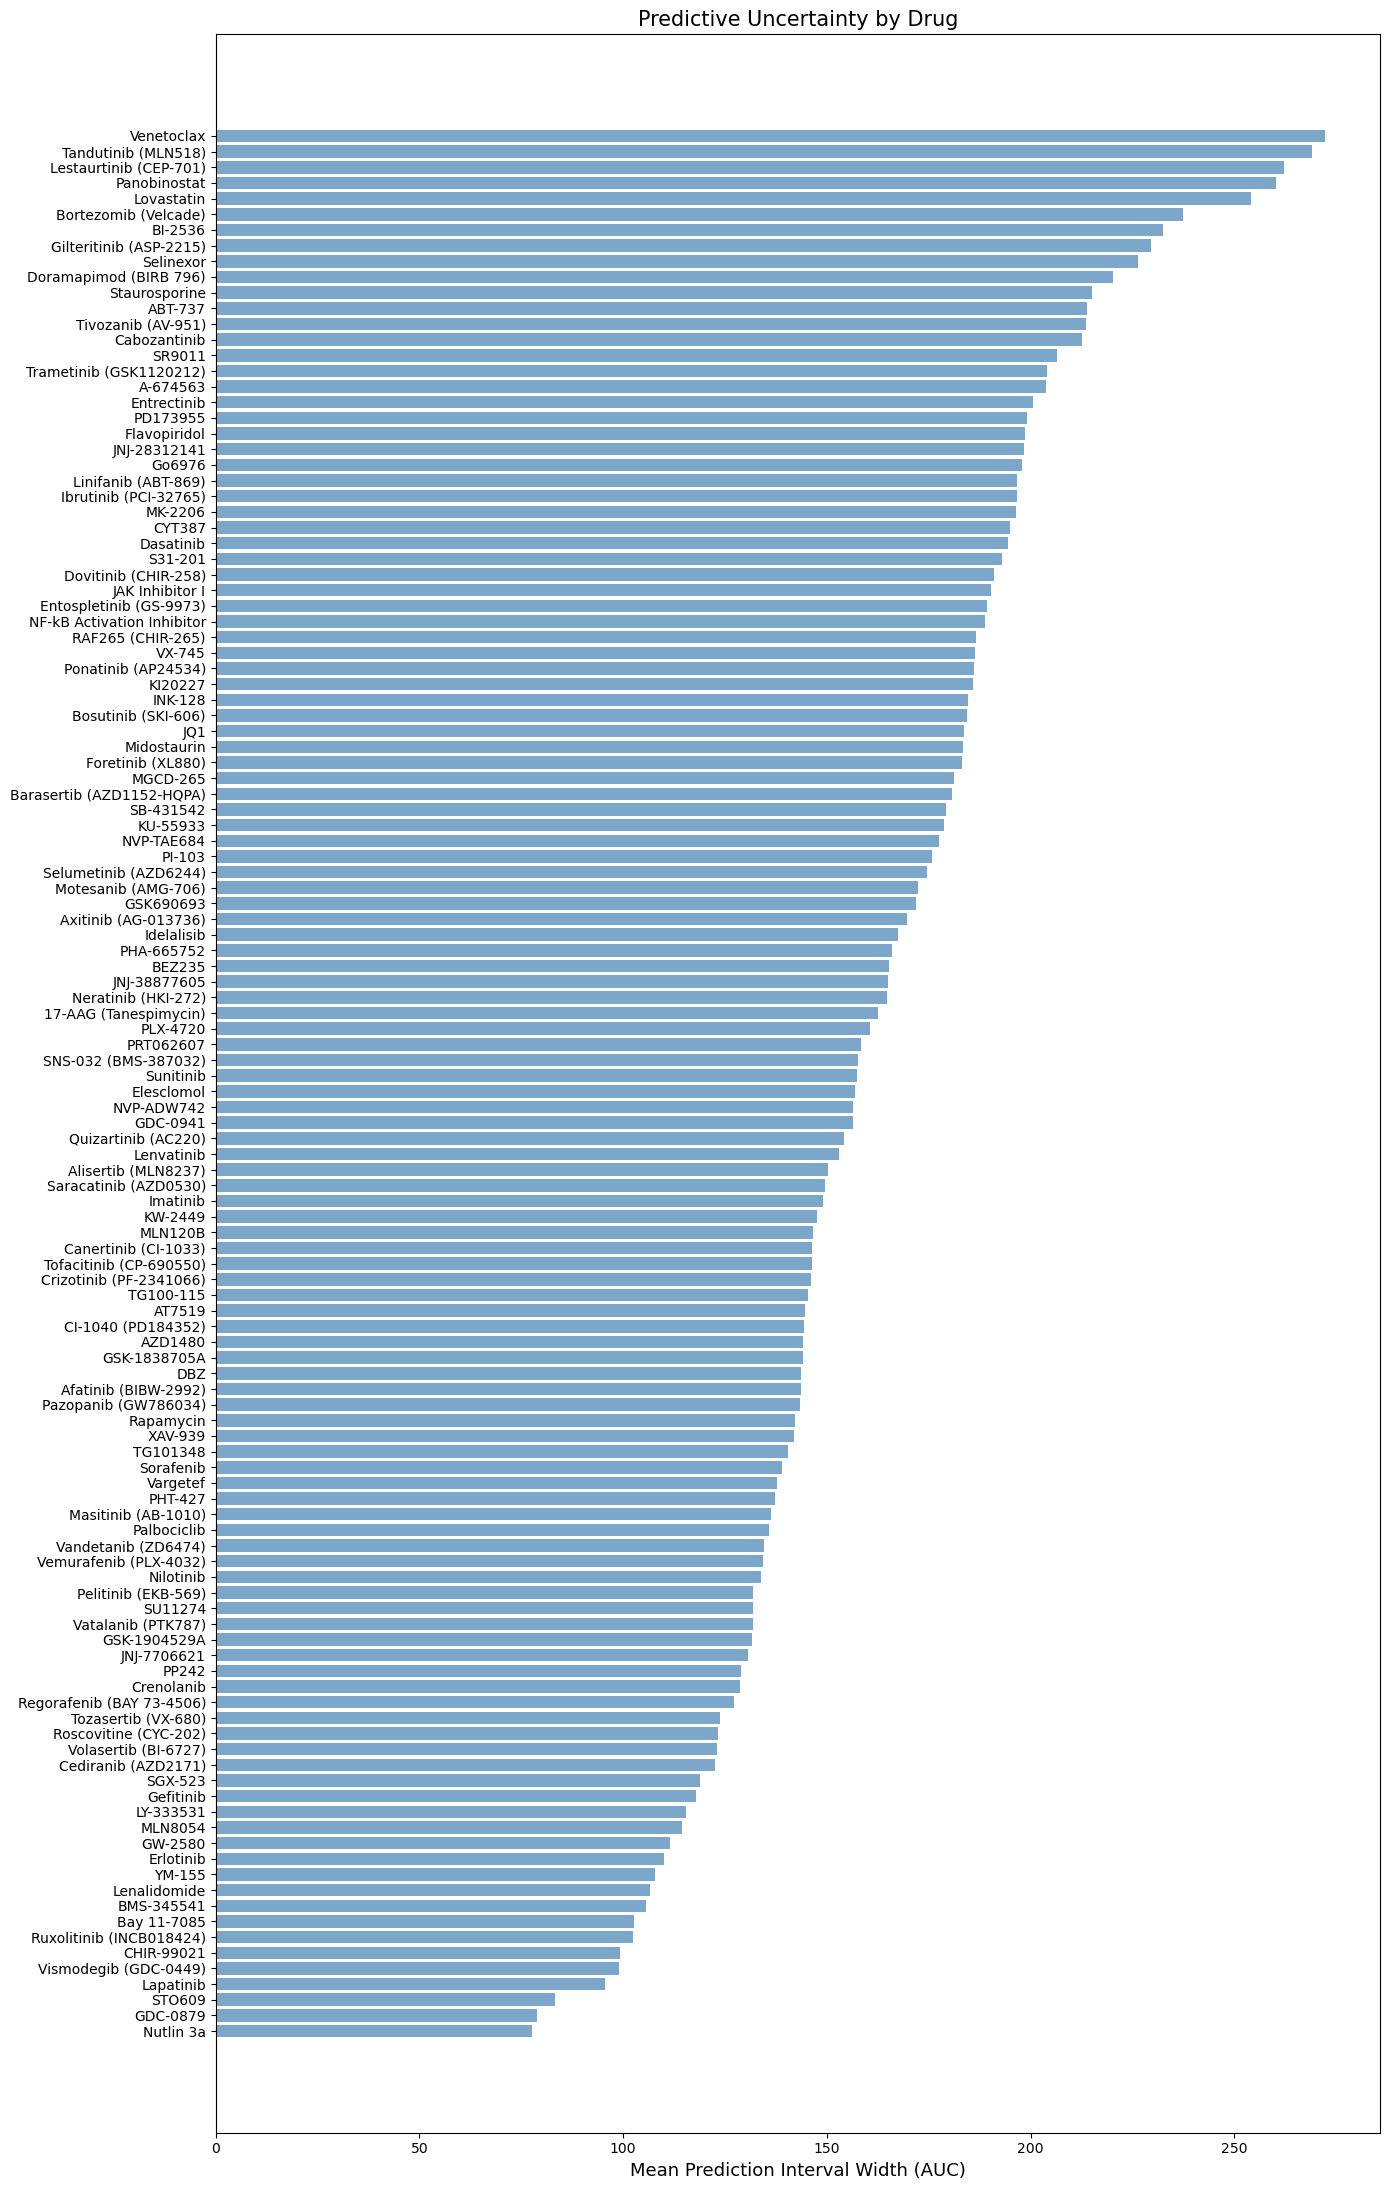

saved.


In [18]:
# drug-level uncertainty analysis

drug_width = merged.groupby('drug')['width'].agg(['mean', 'std', 'count']).reset_index()
drug_width.columns = ['drug', 'mean_width', 'std_width', 'n']
drug_width = drug_width.sort_values('mean_width', ascending=False)

print("top 10 highest uncertainty drugs:")
print(drug_width.head(10)[['drug', 'mean_width', 'std_width']].to_string(index=False))
print("\ntop 10 lowest uncertainty drugs:")
print(drug_width.tail(10)[['drug', 'mean_width', 'std_width']].to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 22))
ax.barh(drug_width['drug'], drug_width['mean_width'], xerr=drug_width['std_width'],
        color='steelblue', alpha=0.7, error_kw={'linewidth': 0.5})
ax.set_xlabel("Mean Prediction Interval Width (AUC)", fontsize=13)
ax.set_title("Predictive Uncertainty by Drug", fontsize=15)
ax.tick_params(axis='y', labelsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures/uncertainty_by_drug.png", dpi=150, bbox_inches='tight')
plt.show()
print("saved.")

mean uncertainty by drug class:
  BCL-2: 272.11 ± 0.00 (n=44)
  HDAC: 260.28 ± 0.00 (n=31)
  FLT3: 193.71 ± 50.30 (n=143)
  MEK: 192.67 ± 12.83 (n=196)
  mTOR: 157.63 ± 19.02 (n=196)
  Hedgehog: 88.96 ± 10.08 (n=126)
  MDM2: 77.53 ± 0.00 (n=38)


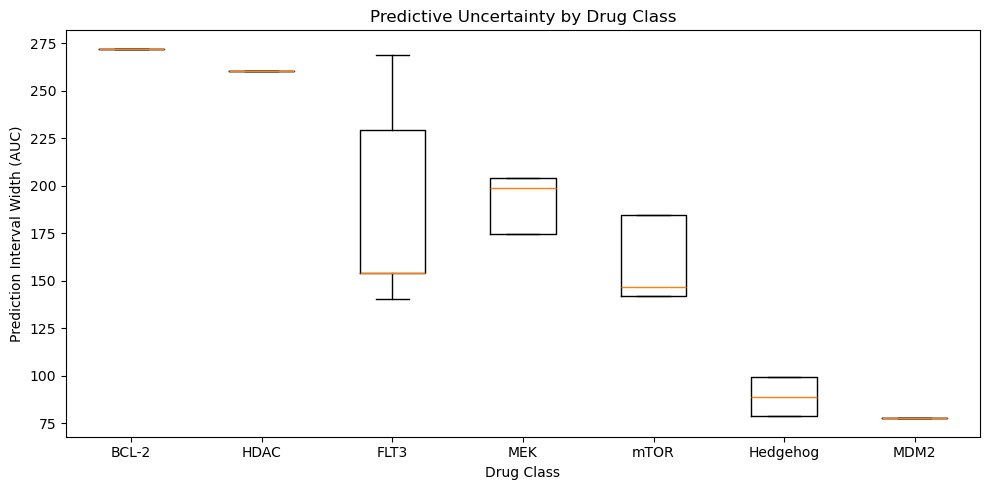

saved.


In [19]:
# drug-class uncertainty analysis

drug_families = {
    'BCL-2': ['Venetoclax', 'Navitoclax (ABT-263)'],
    'FLT3': ['Tandutinib (MLN518)', 'Lestaurtinib (CEP-701)', 'Gilteritinib (ASP-2215)', 
             'TG101348', 'Quizartinib (AC220)'],
    'HDAC': ['Panobinostat', 'Vorinostat (SAHA)', 'Entinostat (MS-275)'],
    'MEK': ['Trametinib (GSK1120212)', 'Selumetinib (AZD6244)', 'PD173955'],
    'mTOR': ['Rapamycin', 'INK-128', 'MLN120B'],
    'MDM2': ['Nutlin 3a'],
    'Hedgehog': ['Vismodegib (GDC-0449)', 'GDC-0879']
}

class_widths = {}
for cls, drugs in drug_families.items():
    widths = merged[merged['drug'].isin(drugs)]['width'].values
    if len(widths) > 0:
        class_widths[cls] = widths

print("mean uncertainty by drug class:")
for cls, widths in sorted(class_widths.items(), key=lambda x: x[1].mean(), reverse=True):
    print(f"  {cls}: {widths.mean():.2f} ± {widths.std():.2f} (n={len(widths)})")

fig, ax = plt.subplots(figsize=(10, 5))
labels = sorted(class_widths.keys(), key=lambda x: class_widths[x].mean(), reverse=True)
ax.boxplot([class_widths[l] for l in labels], tick_labels=labels)
ax.set_ylabel("Prediction Interval Width (AUC)")
ax.set_title("Predictive Uncertainty by Drug Class")
ax.set_xlabel("Drug Class")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures/uncertainty_by_drug_class.png", dpi=150, bbox_inches='tight')
plt.show()
print("saved.")

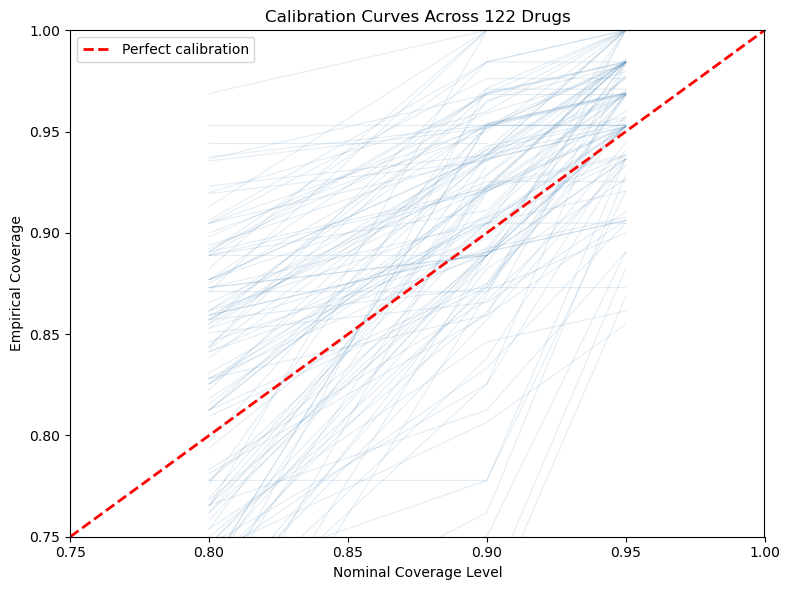

Saved.


In [20]:
# calibration curve per drug

fig, ax = plt.subplots(figsize=(8, 6))

nominal = [0.80, 0.90, 0.95]
for _, row in cp_results.iterrows():
    empirical = [row['coverage_80'], row['coverage_90'], row['coverage_95']]
    empirical = [e for e in empirical if not np.isnan(e)]
    nom = nominal[:len(empirical)]
    ax.plot(nom, empirical, color='steelblue', alpha=0.15, linewidth=0.8)

ax.plot([0.75, 1.0], [0.75, 1.0], 'r--', linewidth=2, label='Perfect calibration')
ax.set_xlabel("Nominal Coverage Level")
ax.set_ylabel("Empirical Coverage")
ax.set_title("Calibration Curves Across 122 Drugs")
ax.legend()
ax.set_xlim(0.75, 1.0)
ax.set_ylim(0.75, 1.0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures/calibration_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("saved.")

In [22]:
# Results

summary = {
    'n_patients': 318,
    'n_drugs': 122,
    'n_patient_drug_pairs': len(uncertainty),
    'median_pearson_en': 0.2915,
    'median_pearson_xgb': 0.2813,
    'coverage_80': cp_results['coverage_80'].mean().round(4),
    'coverage_90': cp_results['coverage_90'].mean().round(4),
    'coverage_95': cp_results['coverage_95'].mean().round(4),
    'mean_width_90': cp_results['width_90'].mean().round(4),
    'eln_kruskal_p': 0.3946,
    'flt3_mannwhitney_p': 0.0136,
    'npm1_mannwhitney_p': 0.7875,
    'highest_uncertainty_drug': 'Venetoclax',
    'lowest_uncertainty_drug': 'Nutlin 3a'
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(RESULTS_DIR / "project_summary.csv", index=False)

print("PROJECT SUMMARY")
print("=" * 30)
for k, v in summary.items():
    print(f"  {k}: {v}")
print("=" * 30)
print("Saved project_summary.csv")

PROJECT SUMMARY
  n_patients: 318
  n_drugs: 122
  n_patient_drug_pairs: 7000
  median_pearson_en: 0.2915
  median_pearson_xgb: 0.2813
  coverage_80: 0.8141
  coverage_90: 0.9074
  coverage_95: 0.955
  mean_width_90: 162.4115
  eln_kruskal_p: 0.3946
  flt3_mannwhitney_p: 0.0136
  npm1_mannwhitney_p: 0.7875
  highest_uncertainty_drug: Venetoclax
  lowest_uncertainty_drug: Nutlin 3a
Saved project_summary.csv


In [3]:
# Run this in notebook 05 or a scratch cell
drug = pd.read_csv(PROC_DIR / "drug_final.csv")

splits_info = []
for drug_name in drug['inhibitor'].unique():
    subset = drug[drug['inhibitor'] == drug_name][['cbio_patient_id','auc']].drop_duplicates()
    subset = subset[subset['cbio_patient_id'].isin(expr.index)]
    n = len(subset)
    splits_info.append({'drug': drug_name, 'n_total': n,
                        'n_calib': int(n*0.2)})
info_df = pd.DataFrame(splits_info)
print(info_df['n_calib'].describe())
print(f"Min calib size: {info_df['n_calib'].min()}")
print(f"Drugs with calib < 20: {(info_df['n_calib'] < 20).sum()}")

NameError: name 'expr' is not defined